In [ ]:
import sys, os
# add repo root to path so `sqw` and `applications` import when running from notebooks/
sys.path.insert(0, os.path.abspath('..'))

In [2]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import time
import os, glob

from applications.qwalkvec import qwalkvec_embedding

In [4]:
G = nx.karate_club_graph()


raw_labels = [G.nodes[i]["club"] for i in G.nodes()]

label_map = {"Mr. Hi": 0, "Officer": 1}
labels = np.array([label_map[c] for c in raw_labels])

# sanity checks
print("nodes:", G.number_of_nodes(), "edges:", G.number_of_edges())
print("connected:", nx.is_connected(G))
print("labels:", np.unique(labels), "counts:", np.bincount(labels))
print("node IDs:", list(G.nodes())[:5], "...")

nodes: 34 edges: 78
connected: True
labels: [0 1] counts: [17 17]
node IDs: [0, 1, 2, 3, 4] ...


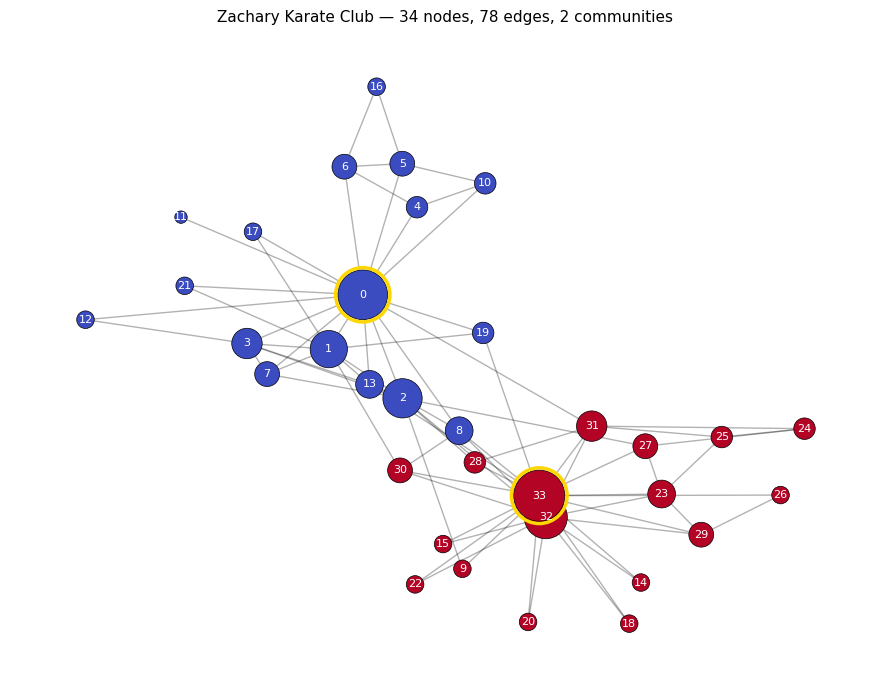

In [5]:
# visualize the Karate club graph, colored by community label
fig, ax = plt.subplots(figsize=(9, 7))

pos = nx.spring_layout(G, seed=42)   # fixed seed -> reproducible layout

# node sizes scaled by degree (hubs stand out)
degrees = dict(G.degree())
node_sizes = [degrees[n] * 80 for n in G.nodes()]

nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.3, width=1.0)
nx.draw_networkx_nodes(
    G, pos, ax=ax,
    node_color=labels,            # 0 / 1 community label
    node_size=node_sizes,
    cmap=plt.cm.coolwarm,
    edgecolors="black", linewidths=0.5,
)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_color="white")

# mark the two hub nodes (0 and 33) the paper highlights in Fig. 1
hubs = [0, 33]
nx.draw_networkx_nodes(
    G, pos, ax=ax, nodelist=hubs,
    node_color="none", node_size=[degrees[h] * 80 + 250 for h in hubs],
    edgecolors="gold", linewidths=2.5,
)

ax.set_title(
    f"Zachary Karate Club — {G.number_of_nodes()} nodes, "
    f"{G.number_of_edges()} edges, 2 communities",
    fontsize=11,
)
ax.axis("off")
plt.tight_layout()
plt.show()

In [9]:
steps = 100
w_p, w_q = 1.0, 1.0   

t0 = time.time()
Phi = qwalkvec_embedding(G, steps=steps, w_p=w_p, w_q=w_q)
print(f"Phi shape: {Phi.shape}  (expected 34 x {steps})")
print(f"elapsed: {time.time() - t0:.1f}s")


# Check 1: normalization.
col_sums = Phi.sum(axis=0)
print("column sums — min:", col_sums.min().round(4),
      "max:", col_sums.max().round(4), "(expected ~34)")

# Check 2: hub dominance (qualitative result from the paper's Fig. 1b).
mean_prob = Phi.mean(axis=1)
top = np.argsort(mean_prob)[::-1][:5]
print("top-5 nodes by mean probability:", top.tolist())
print("  -> should include 0 and 33")

Phi shape: (34, 100)  (expected 34 x 100)
elapsed: 9.5s
column sums — min: 34.0 max: 34.0 (expected ~34)
top-5 nodes by mean probability: [33, 0, 32, 2, 1]
  -> should include 0 and 33


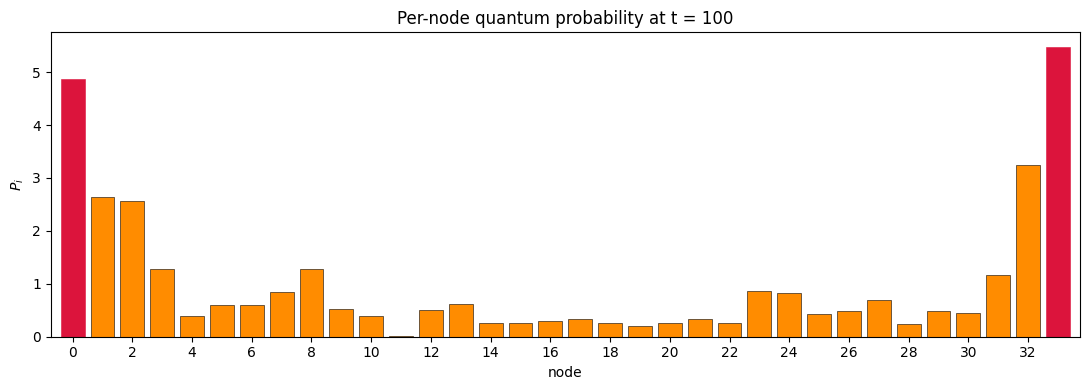

sum over nodes at t=100: 34.0000  (expected ~34)


In [11]:
step_idx = -1   

probs = Phi[:, step_idx]
t_label = Phi.shape[1] if step_idx == -1 else step_idx + 1

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(range(len(probs)), probs, color="darkorange",
              edgecolor="black", linewidth=0.4)

# highlight the two hubs the paper calls out
for h in [0, 33]:
    bars[h].set_color("crimson")

ax.set_xlabel("node")
ax.set_ylabel(r"$P_i$")
ax.set_title(f"Per-node quantum probability at t = {t_label}")
ax.set_xticks(range(0, len(probs), 2))
ax.margins(x=0.01)
plt.tight_layout()
plt.show()

print(f"sum over nodes at t={t_label}: {probs.sum():.4f}  (expected ~34)")